<a href="https://colab.research.google.com/github/segomezz/Practica-1-IA/blob/Segomezz-Ontolog%C3%ADas/Pr%C3%A1ctica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.3. Ontología y Razonamiento Semántico (RDFLib y OWL-RL)

In [1]:
!pip install rdflib
!pip install owlrl
!pip install scikit-fuzzy

In [2]:
from rdflib import Graph, Namespace, RDF, RDFS, Literal, XSD, URIRef
from rdflib.namespace import FOAF, DC
from owlrl import DeductiveClosure, RDFS_Semantics

* Implementación de la Ontología del dominio utilizando RDF y RDFS.
  * El lenguaje de serialización de la ontología final desarrollada será en
Turtle.

  * Implementar al menos 10 clases (rdfs:Class) y 5 relaciones jerárquicas
(rdfs:subClassOf).

A continuación se realiza la definición de un diccionario llamada clases en el cual se establecen clase : subclases. Luego ese se recorre y se le da a cada clase y super clase su URI

In [3]:
# Namespaces
INV = Namespace("http://example.org/inversiones#")

# Crear el grafo
g = Graph()
g.bind("inv", INV)
g.bind("foaf", FOAF)
g.bind("dc", DC)

# Clases (10 clases + jerarquías)
clases = {
    "Inversion": None,
    "Activo": "Inversion",
    "Riesgo": "Inversion",
    "PerfilInversionista": "foaf:Person",
    "Recomendacion": None,
    "Accion": "Activo",
    "Bonos": "Activo",
    "Criptoactivo": "Activo",
    "InversionConservadora": "Inversion",
    "InversionAgresiva": "Inversion",
}

for clase, superclase in clases.items():
    clase_uri = INV[clase]
    g.add((clase_uri, RDF.type, RDFS.Class))
    if superclase:
        if ":" in superclase:
            prefix, name = superclase.split(":")
            super_uri = FOAF[name] if prefix == "foaf" else DC[name]
        else:
            super_uri = INV[superclase]
        g.add((clase_uri, RDFS.subClassOf, super_uri))



* Crear al menos 10 propiedades RDF originales con dominios
(rdfs:domain) y rangos (rdfs:range) correctamente definidos.
    * Incluir al menos un caso de jerarquía (rdfs:subPropertyOf)
    * Incluir como rangos valores tanto de tipo clase (URIs) y otros Tipo
Literales con sus respectivos tipados usando el XML-Schema.

  * Incluir el uso de clases o propiedades provenientes de vocabularios definidos y aceptados en la literatura (FOAF, Dublin Core, etc.).
  *Instanciar al menos 4 individuos por clase

  Se crea un Diccionario con las 10 propiedades y una subpropiedad. Acada propiedad se le asigna su Uri y de igual manera para el rango y el dominio

  Finalmente se realizan las 4 instancias

In [11]:
# Propiedades RDF (11 propiedades)
propiedades = {
    "riesgoAsociado": ("Inversion", "Riesgo"),
    "recomendadaPara": ("Recomendacion", "PerfilInversionista"),
    "tipoActivo": ("Inversion", "Activo"),
    "monto": ("Inversion", XSD.decimal),
    "rendimientoEsperado": ("Inversion", XSD.float),
    "edadInversionista": ("PerfilInversionista", XSD.integer),
    "nivelRiesgo": ("Riesgo", XSD.float),
    "recomienda": ("PerfilInversionista", "Recomendacion"),
    "descripcion": ("Inversion", XSD.string),
    "activoRecomendado": ("Recomendacion", "Activo"),
    "horizonte" :("Inversion",XSD.integer)
}
# Subproperty example
subproperties = {
    "activoEspecifico": "activoRelacionado",
}

for prop, (dom, ran) in propiedades.items():
    prop_uri = INV[prop]
    g.add((prop_uri, RDF.type, RDF.Property))
    g.add((prop_uri, RDFS.domain, INV[dom] if isinstance(dom, str) and ":" not in dom else FOAF[dom]))
    if isinstance(ran, URIRef):
        g.add((prop_uri, RDFS.range, ran))
    elif isinstance(ran, str) and ":" not in ran:
        g.add((prop_uri, RDFS.range, INV[ran]))
    else:
        g.add((prop_uri, RDFS.range, ran))

for child, parent in subproperties.items():
    g.add((INV[child], RDFS.subPropertyOf, INV[parent]))

# Instancias (4 por clase)
for i in range(1, 5):
    inv = INV[f"Inversion{i}"]
    g.add((inv, RDF.type, INV["InversionConservadora"]))
    g.add((inv, INV["descripcion"], Literal(f"Inversión conservadora {i}", datatype=XSD.string)))
    g.add((inv, INV["monto"], Literal(1000 * i, datatype=XSD.decimal)))
    g.add((inv, INV["rendimientoEsperado"], Literal(5 * i, datatype=XSD.float)))
    g.add((inv, INV["tipoActivo"], INV["Bonos"]))
    g.add((inv, INV["horizonte"], Literal(5 * i, datatype=XSD.integer)))

    perfil = INV[f"Inversionista{i}"]
    g.add((perfil, RDF.type, INV["PerfilInversionista"]))
    g.add((perfil, FOAF.name, Literal(f"Inversionista {i}")))
    g.add((perfil, INV["edadInversionista"], Literal(30 + i, datatype=XSD.integer)))

    riesgo = INV[f"Riesgo{i}"]
    g.add((riesgo, RDF.type, INV["Riesgo"]))
    g.add((riesgo, INV["nivelRiesgo"], Literal(3.0, datatype=XSD.float)))
    g.add((inv, INV["riesgoAsociado"], riesgo))

    recomendacion = INV[f"Recomendacion{i}"]
    g.add((recomendacion, RDF.type, INV["Recomendacion"]))
    g.add((recomendacion, INV["recomendadaPara"], perfil))
    g.add((recomendacion, INV["activoEspecifico"], INV["Bonos"]))


  * Aplicar razonamiento sobre la ontología RDFS anteriormente desarrollada usando DeductiveClosure(RDFS Semantics) de owlrl.
    * Completar de ser necesario la antología desarrollada para realizar lo siguiente:
    ** Documentar al menos dos casos de generación de nuevos hechos asociados a una jerarquía de clases (ver caso 1 de las diapositivas)

    * * Documentar la asociación de un caso de miembro de una clase desde el dominio o rango de sus propiedades (ver caso 2 de las diapositivas)
    ** Documentar un caso de nuevos hechos desde la relación
subproperty (ver caso 3 de las diapositivas)
    ** Todos los tres requerimientos anteriores, deben ser generados al usar el razonador OWL-RL usando DeductiveClosure(RDFS Semantics) sobre la ontología final de su dominio.

    * Comparar el grafo antes y después del razonamiento para evidenciar nuevas afirmaciones inferidas automáticamente.
    * Adicionalmente a lo anteriormente requerido se debe evidenciar al menos 4 nuevos hechos inferidos generados como resultado del razonamiento.

In [5]:
# Grafo original
grafo_antes = g.serialize(format="turtle").splitlines()
print(g.serialize(format="turtle"))

@prefix foaf: <http://xmlns.com/foaf/0.1/> .
@prefix inv: <http://example.org/inversiones#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

inv:Accion a rdfs:Class ;
    rdfs:subClassOf inv:Activo .

inv:Activo a rdfs:Class ;
    rdfs:subClassOf inv:Inversion .

inv:Bonos a rdfs:Class ;
    rdfs:subClassOf inv:Activo .

inv:Criptoactivo a rdfs:Class ;
    rdfs:subClassOf inv:Activo .

inv:Inversion a rdfs:Class .

inv:InversionAgresiva a rdfs:Class ;
    rdfs:subClassOf inv:Inversion .

inv:InversionConservadora a rdfs:Class ;
    rdfs:subClassOf inv:Inversion .

inv:PerfilInversionista a rdfs:Class ;
    rdfs:subClassOf foaf:Person .

inv:Recomendacion a rdfs:Class .

inv:Riesgo a rdfs:Class ;
    rdfs:subClassOf inv:Inversion .

inv:Inversion1 a inv:InversionConservadora ;
    inv:descripcion "Inversión conservadora 1"^^xsd:string ;
    inv:horizonte 5 ;
    inv:

In [6]:
# Razonamiento
DeductiveClosure(RDFS_Semantics).expand(g)

In [7]:
# Serialización después del razonamiento
grafo_despues = g.serialize(format="turtle").splitlines()
print(g.serialize(format="turtle"))




@prefix foaf: <http://xmlns.com/foaf/0.1/> .
@prefix inv: <http://example.org/inversiones#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

inv:Accion a rdfs:Class,
        rdfs:Resource ;
    rdfs:subClassOf inv:Accion,
        inv:Activo,
        inv:Inversion,
        rdfs:Resource .

inv:Activo a rdfs:Class,
        rdfs:Resource ;
    rdfs:subClassOf inv:Activo,
        inv:Inversion,
        rdfs:Resource .

inv:Bonos a inv:Activo,
        inv:Inversion,
        rdfs:Class,
        rdfs:Resource ;
    rdfs:subClassOf inv:Activo,
        inv:Bonos,
        inv:Inversion,
        rdfs:Resource .

inv:Criptoactivo a rdfs:Class,
        rdfs:Resource ;
    rdfs:subClassOf inv:Activo,
        inv:Criptoactivo,
        inv:Inversion,
        rdfs:Resource .

inv:Inversion a rdfs:Class,
        rdfs:Resource ;
    rdfs:subClassOf inv:Inversion,
        rdfs:Resource

Debido al tamaño del grafo no fue posible mostrarlo, por lo que vamos a mirar la diferencia entre los grafos en el formato turtle para analizar las inferencias

In [8]:
# Convertir a conjuntos de líneas para comparar
set_antes = set(grafo_antes)
set_despues = set(grafo_despues)

# Obtener nuevos triples inferidos (presentes después, no antes)
inferidos = set_despues - set_antes

# Mostrar los nuevos hechos
print("🔍 Nuevos hechos inferidos:\n")
for triple in sorted(inferidos):
    print(triple)

🔍 Nuevos hechos inferidos:

        "10"^^xsd:float ;
        "15"^^xsd:float ;
        "20"^^xsd:float ;
        "5"^^xsd:float ;
        10 ;
        15 ;
        20 ;
        5 ;
        foaf:Person .
        foaf:Person ;
        inv:Activo,
        inv:Bonos,
        inv:Criptoactivo,
        inv:Inversion,
        inv:InversionAgresiva,
        inv:InversionConservadora,
        inv:Riesgo,
        inv:activoRelacionado .
        rdfs:Class,
        rdfs:Resource .
        rdfs:Resource ;
        rdfs:Resource,
        xsd:decimal .
        xsd:float .
        xsd:float,
        xsd:integer .
        xsd:string .
    inv:activoRelacionado inv:Bonos ;
    inv:horizonte 10,
    inv:horizonte 15,
    inv:horizonte 20,
    inv:horizonte 5,
    inv:rendimientoEsperado "10"^^xsd:float,
    inv:rendimientoEsperado "15"^^xsd:float,
    inv:rendimientoEsperado "20"^^xsd:float,
    inv:rendimientoEsperado "5"^^xsd:float,
    rdfs:range inv:Activo ;
    rdfs:range inv:PerfilInversionista ;


# 2.2 Sistema de lógica difusa (Scikit-Fuzzy)

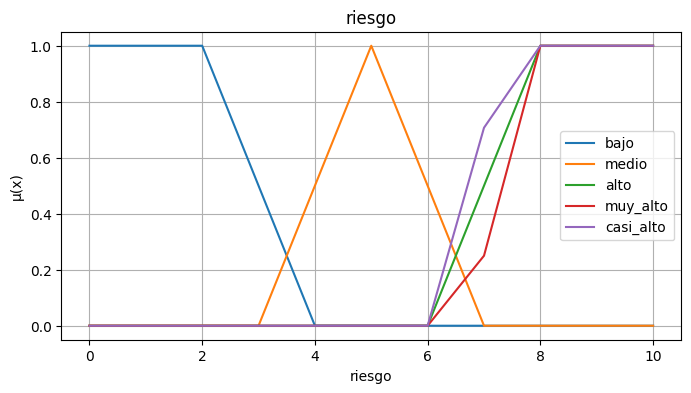

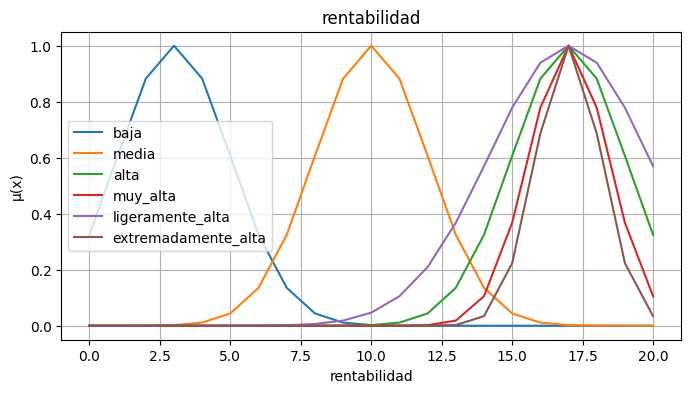

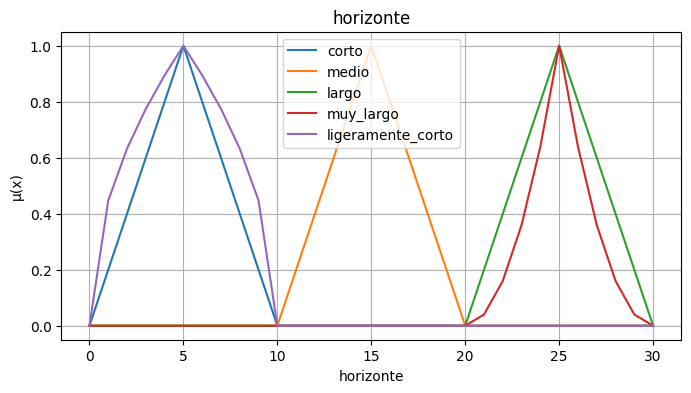

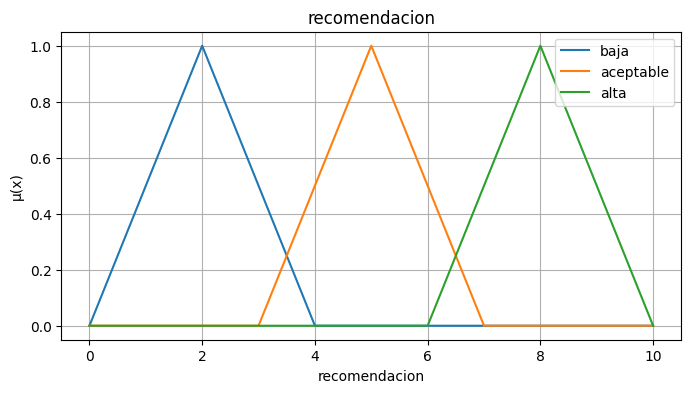

Nivel de recomendación: 6.5
Clasificación: Aceptable


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1. Variables y rangos
riesgo = ctrl.Antecedent(np.arange(0, 11, 1), 'riesgo')
rentabilidad = ctrl.Antecedent(np.arange(0, 21, 1), 'rentabilidad')
horizonte = ctrl.Antecedent(np.arange(0, 31, 1), 'horizonte')
recomendacion = ctrl.Consequent(np.arange(0, 11, 1), 'recomendacion')
recomendacion.defuzzify_method = 'centroid'

# 2. Funciones de pertenencia

# Riesgo
riesgo['bajo'] = fuzz.trapmf(riesgo.universe, [0, 0, 2, 4])
riesgo['medio'] = fuzz.trimf(riesgo.universe, [3, 5, 7])
riesgo['alto'] = fuzz.trapmf(riesgo.universe, [6, 8, 10, 10])
riesgo['muy_alto'] = np.power(riesgo['alto'].mf, 2)
riesgo['casi_alto'] = np.sqrt(riesgo['alto'].mf)

# Rentabilidad
rentabilidad['baja'] = fuzz.gaussmf(rentabilidad.universe, 3, 2)
rentabilidad['media'] = fuzz.gaussmf(rentabilidad.universe, 10, 2)
rentabilidad['alta'] = fuzz.gaussmf(rentabilidad.universe, 17, 2)
rentabilidad['muy_alta'] = np.power(rentabilidad['alta'].mf, 2)
rentabilidad['ligeramente_alta'] = np.sqrt(rentabilidad['alta'].mf)
rentabilidad['extremadamente_alta'] = np.power(rentabilidad['alta'].mf, 3)

# Horizonte
horizonte['corto'] = fuzz.trimf(horizonte.universe, [0, 5, 10])
horizonte['medio'] = fuzz.trimf(horizonte.universe, [10, 15, 20])
horizonte['largo'] = fuzz.trimf(horizonte.universe, [20, 25, 30])
horizonte['muy_largo'] = np.power(horizonte['largo'].mf, 2)
horizonte['ligeramente_corto'] = np.sqrt(horizonte['corto'].mf)

# Recomendación
recomendacion['baja'] = fuzz.trimf(recomendacion.universe, [0, 2, 4])
recomendacion['aceptable'] = fuzz.trimf(recomendacion.universe, [3, 5, 7])
recomendacion['alta'] = fuzz.trimf(recomendacion.universe, [6, 8, 10])

# 3. Graficas funciones de pertenencia

def mostrar_funciones(var, nombre):
    plt.figure(figsize=(8, 4))
    for etiqueta in var.terms:
        plt.plot(var.universe, var[etiqueta].mf, label=etiqueta)
    plt.title(f'{nombre}')
    plt.xlabel(nombre)
    plt.ylabel('μ(x)')
    plt.grid(True)
    plt.legend()
    plt.show()

mostrar_funciones(riesgo, 'riesgo')
mostrar_funciones(rentabilidad, 'rentabilidad')
mostrar_funciones(horizonte, 'horizonte')
mostrar_funciones(recomendacion, 'recomendacion')

# 4. Reglas
rules = [
    ctrl.Rule(riesgo['bajo'] & rentabilidad['alta'], recomendacion['alta']),
    ctrl.Rule(riesgo['alto'] & rentabilidad['baja'], recomendacion['baja']),
    ctrl.Rule(riesgo['medio'] & rentabilidad['media'], recomendacion['aceptable']),
    ctrl.Rule(riesgo['bajo'] | horizonte['largo'], recomendacion['alta']),
    ctrl.Rule(riesgo['alto'] & horizonte['corto'], recomendacion['baja']),
    ctrl.Rule(~riesgo['alto'] & rentabilidad['alta'], recomendacion['alta']),
    ctrl.Rule(riesgo['medio'] & horizonte['medio'], recomendacion['aceptable']),
    ctrl.Rule(rentabilidad['baja'] & horizonte['largo'], recomendacion['aceptable']),
    ctrl.Rule(riesgo['alto'] | rentabilidad['alta'], recomendacion['aceptable']),
    ctrl.Rule(riesgo['bajo'] & rentabilidad['muy_alta'], recomendacion['alta']),
    ctrl.Rule(riesgo['medio'] & rentabilidad['ligeramente_alta'], recomendacion['aceptable']),
    ctrl.Rule(riesgo['bajo'] & horizonte['muy_largo'], recomendacion['alta']),
    ctrl.Rule(riesgo['muy_alto'] & horizonte['corto'], recomendacion['baja']),
    ctrl.Rule(rentabilidad['extremadamente_alta'] & riesgo['bajo'], recomendacion['alta']),
    ctrl.Rule(horizonte['ligeramente_corto'] & rentabilidad['media'], recomendacion['aceptable']),
    ctrl.Rule(riesgo['casi_alto'] & rentabilidad['media'], recomendacion['aceptable']),
    ctrl.Rule(horizonte['medio'] & rentabilidad['muy_alta'], recomendacion['alta']),
    ctrl.Rule(riesgo['bajo'] & rentabilidad['baja'], recomendacion['aceptable']),
]

# 5. Crear sistema y simular
sistema_ctrl = ctrl.ControlSystem(rules)
sistema = ctrl.ControlSystemSimulation(sistema_ctrl)

# Datos de prueba
sistema.input['riesgo'] = 3
sistema.input['rentabilidad'] = 18
sistema.input['horizonte'] = 12

sistema.compute()

def clasificar_recomendacion(valor):
    if valor < 3.5:
        return "Baja"
    elif valor < 6.5:
        return "Aceptable"
    else:
        return "Alta"

nivel = sistema.output['recomendacion']
print("Nivel de recomendación:", round(nivel, 2))
print("Clasificación:", clasificar_recomendacion(nivel))

## Integración módulo Ontologías y Lógica Difusa

In [12]:

# --------------------------------------
# 1. Asegurar propiedad 'nivelRecomendacion' en la ontología
# --------------------------------------
nivelRecom = INV["nivelRecomendacion"]
g.add((nivelRecom, RDF.type, RDF.Property))
g.add((nivelRecom, RDFS.domain, INV["Recomendacion"]))
g.add((nivelRecom, RDFS.range, XSD.string))

# --------------------------------------
# 2. Función para extraer datos de una inversión del grafo RDF
# --------------------------------------
def obtener_datos_inversion(grafo, inversion_uri):
    riesgo_val = None
    rendimiento = None
    horizonte = None

    # Extraer rendimientoEsperado
    for _, _, o in grafo.triples((inversion_uri, INV["rendimientoEsperado"], None)):
        rendimiento = float(o)

    # Extraer horizonte
    for _, _, o in grafo.triples((inversion_uri, INV["horizonte"], None)):
        horizonte = int(o)

    # Extraer nivelRiesgo desde recurso Riesgo relacionado
    for _, _, riesgo_uri in grafo.triples((inversion_uri, INV["riesgoAsociado"], None)):  # 🔧 importante: usar "tieneRiesgo"
        for _, _, o2 in grafo.triples((riesgo_uri, INV["nivelRiesgo"], None)):
            riesgo_val = float(o2)

    return riesgo_val, rendimiento, horizonte

# --------------------------------------
# 3. Simulación del sistema difuso
# --------------------------------------

# Selecciona la inversión a analizar
inversion_uri = INV["Inversion1"]

# Obtener valores desde RDF
riesgo, rendimiento, horizonte = obtener_datos_inversion(g, inversion_uri)

print(f"Datos extraídos de RDF:")
print(f"- Riesgo: {riesgo}")
print(f"- Rendimiento esperado: {rendimiento}")
print(f"- Horizonte: {horizonte}")

# Configurar el sistema difuso (debes haber ejecutado el código original del sistema difuso antes)
sistema = ctrl.ControlSystemSimulation(sistema_ctrl)
sistema.input['riesgo'] = riesgo
sistema.input['rentabilidad'] = rendimiento
sistema.input['horizonte'] = horizonte
sistema.compute()

# Obtener resultado
nivel_recomendacion = sistema.output['recomendacion']

# Clasificar en términos lingüísticos
def clasificar(valor):
    if valor < 3.5:
        return "Baja"
    elif valor < 6.5:
        return "Aceptable"
    else:
        return "Alta"

clasificacion = clasificar(nivel_recomendacion)

# Mostrar resultado
print("\n🔍 Resultado del sistema difuso:")
print("Nivel numérico:", round(nivel_recomendacion, 2))
print("Clasificación:", clasificacion)


Datos extraídos de RDF:
- Riesgo: 3.0
- Rendimiento esperado: 5.0
- Horizonte: 5

🔍 Resultado del sistema difuso:
Nivel numérico: 6.5
Clasificación: Aceptable
